# Testing scipy linear programming

## Imports, definitions and base tests

In [1]:
# Module imports
import sys

import numpy as np
import scipy as sp
from loguru import logger



In [2]:
# Set up the logger
logger.remove()
logger.add(
    sink=sys.stdout,
    format="<level>{level:<10} | {message}</>",
    level="INFO",
    colorize=True,
)

1

### Behaviors as vectors and notation

Suppose a (2,2,2) routed Bell experiment.

$ p(ab|xyz) \in \mathbb{R}^{32}$ is the observed behavior, assumed to be no-signaling : $$p \in \mathcal{NS}$$

We wish for easy conversion from a vector format (for algebraic operations) to a matrix format (for leggibility) :
$$p=\begin{pmatrix} p_{00|00S} \\ p_{00|01S} \\ \vdots \\ p_{00|00L} \\ \vdots \end{pmatrix}\quad \leftrightarrow \quad p=\begin{pmatrix} p_{00|00}& p_{00|01}& p_{00|10}& p_{00|11}\\ p_{01|00}& p_{01|01}& \dots\\ \vdots & & \ddots \\ & & & p_{11|11} \end{pmatrix}$$
where, to account for both matrices $p(z=S)$ and $p(z=L)$, both cases are represented in two matrices, making $p$ either a column vector in $\mathbb{R}^{32}$ or a third-order tensor of shape $(2,4,4)$.

We defined in the Behavior class (behavior.py) some utility functions.

In [3]:
from behaviors import Behavior

# The maximally mixed state over the experiment space
I = Behavior((1 / 4) * np.ones(32))  # noqa: E741

# The usual (2,2,2) PR box
SR_pr_box = np.array(
    [ 1/2, 1/2, 1/2, 0, 0, 0, 0, 1/2, 0, 0, 0, 1/2, 1/2, 1/2, 1/2, 0]
)

# The PR box in the experiment space : p(ab|xy) is assumed to be
# independent of the value of z
pr_box = Behavior(np.concatenate((SR_pr_box, SR_pr_box), axis=0))

def to_behavior(arr):
    return Behavior(np.concatenate((arr, arr), axis=0))

non_positive_arr = np.array(
    [-1/2,-1/2,-1/2,0,0,0,0,1/2,0,0,0,1/2,1/2,1/2,1/2,0,],
)
non_normalized_arr = np.array(
    [1/2,1/2,1/2,0,0,0,0,0,0,0,0,1/2,1/2,1/2,1/2,0,]
)
non_ns_arr = np.array(
    [1/2,1/2,0,0,0,0,1/2,1/2,1/2,1/2,0,0,0,0,1/2,1/2,]
)

non_positive = to_behavior(non_positive_arr)
non_normalized = to_behavior(non_normalized_arr)
non_ns = to_behavior(non_ns_arr)


In [4]:
# Sanity check cell, don't mind me

# print("PR box: ", pr_box)
# print("I: ", I)

print("I == I: ", I == I)
print("I == pr_box: ", I == pr_box)
print("I == 0: ", I == 0)
print("I == 0.25: ", I == 0.25)
print("pr_box == pr_box_array: ", pr_box == np.concatenate((SR_pr_box, SR_pr_box), axis=0))

print("I positive: ", I.positivity())
print("I normalized: ", I.normalization())
print("I no-signaling: ", I.no_signaling())

print("PR box positive: ", pr_box.positivity())
print("PR box normalized: ", pr_box.normalization())
print("PR box no-signaling: ", pr_box.no_signaling())

print("Non-positive: ", non_positive.positivity())
print("Non-normalized: ", non_normalized.normalization())
print("Non-no-signaling: ", non_ns.no_signaling())

print("Non-no-signaling is normalized: ", non_ns.is_normalized())

I == I:  True
I == pr_box:  False
I == 0:  False
I == 0.25:  True
pr_box == pr_box_array:  True
I positive:  True
I normalized:  True
I no-signaling:  True
PR box positive:  True
PR box normalized:  True
PR box no-signaling:  True
Non-positive:  False
Non-normalized:  False
Non-no-signaling:  False
Non-no-signaling is normalized:  True


In [5]:
# Checking the indices correspondence functions

from behaviors import routed_index_to_indices, routed_indices_to_index

for i in range(2*2**2*2**2):
    print(f"i={i} -> routed index: {routed_index_to_indices(i, m=2)}, computed i: {routed_indices_to_index(*routed_index_to_indices(i,m=2), m=2)}")  # noqa: E501

i=0 -> routed index: (0, 0, 0, 0, 0), computed i: 0
i=1 -> routed index: (0, 0, 0, 1, 0), computed i: 1
i=2 -> routed index: (0, 0, 1, 0, 0), computed i: 2
i=3 -> routed index: (0, 0, 1, 1, 0), computed i: 3
i=4 -> routed index: (0, 1, 0, 0, 0), computed i: 4
i=5 -> routed index: (0, 1, 0, 1, 0), computed i: 5
i=6 -> routed index: (0, 1, 1, 0, 0), computed i: 6
i=7 -> routed index: (0, 1, 1, 1, 0), computed i: 7
i=8 -> routed index: (1, 0, 0, 0, 0), computed i: 8
i=9 -> routed index: (1, 0, 0, 1, 0), computed i: 9
i=10 -> routed index: (1, 0, 1, 0, 0), computed i: 10
i=11 -> routed index: (1, 0, 1, 1, 0), computed i: 11
i=12 -> routed index: (1, 1, 0, 0, 0), computed i: 12
i=13 -> routed index: (1, 1, 0, 1, 0), computed i: 13
i=14 -> routed index: (1, 1, 1, 0, 0), computed i: 14
i=15 -> routed index: (1, 1, 1, 1, 0), computed i: 15
i=16 -> routed index: (0, 0, 0, 0, 1), computed i: 16
i=17 -> routed index: (0, 0, 0, 1, 1), computed i: 17
i=18 -> routed index: (0, 0, 1, 0, 1), computed 

In [6]:
# Checking that the no-signaling set is well defined in no_signaling_set.py

from no_signaling_set import routed_no_signaling_equations
from behaviors import completely_mixed_behavior, pr_box

delta, m = 2, 2
equations, right_side = routed_no_signaling_equations(delta, m)


# print(f"Delta: {delta}, m: {m}")
# print("\n--------------\n")
# print(f"Equations shape: {equations.shape}")
# print("\n--------------\n")

# for line in equations:
#     print(str(line).strip("[]").replace("\n", "").replace(" ", "").replace("-1", "2").replace(".", "").replace("0", "."))  # noqa: E501

# print("\n--------------\n")
# print(f"Right side shape: {right_side.shape}")
# print("\n--------------\n")
# print(f"Right side: {right_side}")


print(np.all(equations @ completely_mixed_behavior.get_vector() == right_side))
print(np.all(equations @ pr_box.get_vector() == right_side))



True
True


## Sampling behaviors

### Uniform on normalized behaviors $\mathcal{B}$

In [7]:
from samplers import UniformNormalizedSampler

sampler = UniformNormalizedSampler(2,2,True) # Samples normalized behaviors

sample_behavior = sampler.sample()
print("Sampled behavior: ", sample_behavior)
print("Sample behavior is normalized: ", sample_behavior.is_normalized())
print("Sample behavior is no-signaling: ", sample_behavior.no_signaling())

Sampled behavior:  Behavior:
Short path (z=S):
[[0.53907813 0.08591517 0.11402739 0.05018786]
 [0.11530526 0.46914343 0.30929809 0.08138137]
 [0.22871367 0.40232232 0.09120914 0.54717521]
 [0.11690294 0.04261908 0.48546539 0.32125556]]
Long path (z=L) :
[[0.33326146 0.23645634 0.13382384 0.27813167]
 [0.14935225 0.10775009 0.3557634  0.26316354]
 [0.34711119 0.28159401 0.39135088 0.44314585]
 [0.17027509 0.37419956 0.11906188 0.01555894]]
------------
Sample behavior is normalized:  True
Sample behavior is no-signaling:  False


Sampling no-signaling behaviors can't reasonably be achieved with rejection sampling from normalized behaviors though, since as $dim(\mathcal{NS}) < dim(\mathcal{B})$, the usual measure of $\mathcal{NS}$ in $\mathcal{B}$ is null. Getting a no-signaling behavior would thus be very, very lucky.

A consequence of this is that we will need to implement uniform sampling on the $\mathcal{NS}$ polytope to sample no-signaling behaviors directly. This can be achieved if we know the polytope's vertices, which is the case in low-dimensions only. The method consists in partitioning the arbitrary bounded polytope in simplices, which we can sample from by weighing them using their volumes, and then using simplex-specific methods to sample uniformly in the chosen simplex.

It also seems that we are able to uniformly sample from a polytope using MCMC methods, as per [Sun and Chen, 2024](https://arxiv.org/abs/2412.06629), using the ``polytopewalk`` module.

### Testing ``polytopewalk``

In [ ]:
import polytopewalk as pw

number_of_samples = int(1e5)
number_to_burn = int(1e3)
walk = pw.sparse.SparseDikinLSWalk()

# Get the equations of the no-signaling set
logger.debug("Getting the equations of the no-signaling set")
A, b = routed_no_signaling_equations(delta=2, m=2)

logger.debug(f"Equations shape: {A.shape}")

# Rank reduce the matrix
logger.debug("Rank reducing the matrix")
U, s, Vh = sp.linalg.svd(A)
rank = np.sum(s > 1e-10)
A_reduced = s[:rank, None] * Vh[:rank, :]  # shape: (rank, n)
b_reduced = (U.T[:rank] @ b).reshape(-1, 1)  # shape: (rank, 1)

# Change to sparse representation
logger.debug("Changing to sparse representation")
A_comp = sp.sparse.csc_matrix(A_reduced, dtype=np.float64)
b_comp = b_reduced.astype(np.float64)

# Get the polytopewalk objects
logger.debug("Getting the polytopewalk objects")
# Facial reduction
logger.debug("Getting the facial reduction object")
fr = pw.FacialReduction()
fr_output = fr.reduce(A_comp, b_comp, k=A_comp.shape[1], sparse=True)
# logger.debug(f"Facial reduction output: {fr_output}")
# logger.debug(f"Facial reduction output Q: {fr_output.Q}")
# logger.debug(f"Facial reduction output z1: {fr_output.z1}")
# logger.debug(f"Facial reduction output A: {fr_output.sparse_A}")
# logger.debug(f"Facial reduction output b: {fr_output.sparse_b}")
# # Center
logger.debug("Getting the center object")
# z_custom = np.linalg.lstsq(
#     fr_output.Q, completely_mixed_behavior.get_vector() - fr_output.z1, rcond=None
#     )[0]
# class CustomCenter(pw.sparse.SparseCenter):
#     def getInitialPoint(self, A, b, k):
#         return completely_mixed_behavior.get_vector()
# sc = CustomCenter()
sc = pw.sparse.SparseCenter()
logger.debug(f"Test center point: {sc.getInitialPoint(fr_output.sparse_A, fr_output.sparse_b, rank)}")

# # Run the MCMC
logger.debug("Running the MCMC")
samples_comp = pw.sparseFullWalkRun(
    A=fr_output.sparse_A,
    b=fr_output.sparse_b,
    k=A_comp.shape[1],
    num_sim=number_of_samples,
    walk=walk,
    fr=fr,
    sc=sc,
    burn=number_to_burn,
    )

# Map back to the original space
logger.debug("Mapping back to the original space")
if fr_output.Q is not None and fr_output.Q.size > 0:
    logger.debug(f"Mapping back to the original space with Q: {fr_output.Q}")
    samples_og = (fr_output.Q @ samples_comp.T).T + fr_output.z1.T
else:
    logger.debug("Already in the original space, no mapping needed")
    samples_og = samples_comp  # Already in original space
logger.success(f"Samples shape: {samples_og.shape}")

# Check that the point is in the no-signaling set
logger.debug("Checking that the points are in the no-signaling set")
all_samples_good = True
all_samples_count = 0
bad_samples_count = 0
for vec in samples_og:
    all_samples_count += 1
    # Check that the point is in the no-signaling set
    behavior = Behavior(vec)
    if not behavior.is_no_signaling():
        all_samples_good = False
        bad_samples_count += 1
        logger.error(f"Point is not in the no-signaling set:{behavior}")
if all_samples_good:
    logger.success(f"All {all_samples_count} points are in the no-signaling set")
else:
    logger.error(f"Some points are not in the no-signaling set ({bad_samples_count}/{all_samples_count})")

# Reminder of the no-signaling check procedure
# from behaviors import display_ns_test_arrays
# display_ns_test_arrays(sum_over_b=False, verbose=True)
# display_ns_test_arrays(sum_over_b=True)


SUCCESS    | Samples shape: (100000, 32)
SUCCESS    | All 100000 points are in the no-signaling set


### Plotting the uniform sampling in a random plane

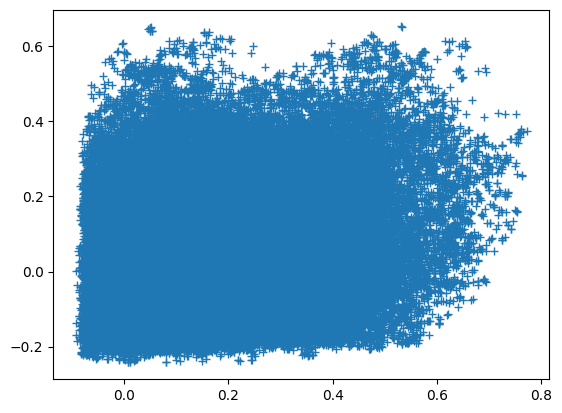

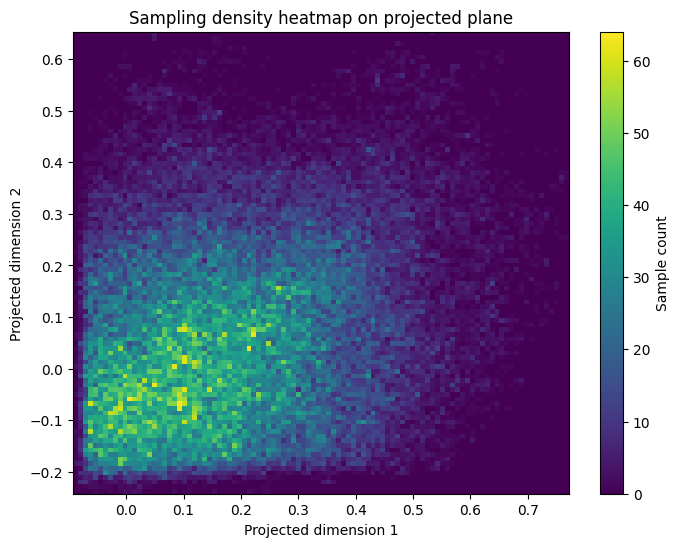

In [12]:
# Pick a random behavior from the samples
from random import choice

import matplotlib.pyplot as plt

ref_vector = choice(samples_og)

# Build a projector onto a plane orthogonal to the vector
def projector(v):
    """
    Build a projector onto a plane orthogonal to the vector v
    v is assumed to be normalized
    """
    # Get the dimension of the vector
    d = len(v)
    # Build the projector matrix
    P = np.eye(d) - np.outer(v, v)/np.dot(v, v)    
    indices = np.random.choice(range(d), 2, replace=False)
    return P[indices,:]  # Keep only the first two rows to get a 2D projector
proj = projector(ref_vector)

# Project the samples onto the plane
projected_samples = np.dot(proj, samples_og.T).T

# Plot the samples

plt.plot(projected_samples[:,0], projected_samples[:,1], '+')
plt.show()

# Plot a 2D histogram (heatmap) of the projected samples
plt.figure(figsize=(8, 6))
plt.hist2d(projected_samples[:, 0], projected_samples[:, 1], bins=100, cmap='viridis')
plt.colorbar(label='Sample count')
plt.xlabel('Projected dimension 1')
plt.ylabel('Projected dimension 2')
plt.title('Sampling density heatmap on projected plane')
plt.show()

### Checking uniformity

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import pdist
from sklearn.neighbors import NearestNeighbors


def global_analyze_sampling(points, plot=True):
    """
    Analyze the uniformity of a set of sampled points using pairwise distances.

    Parameters
    ----------
    points : ndarray
        Array of shape (N, d) where each row is a sample in R^d.
    plot : bool
        Whether to plot a histogram of pairwise distances.

    Returns
    -------
    dict
        Summary statistics: mean, std, min, max of pairwise distances.
    """
    if points.ndim != 2:
        raise ValueError("Input must be a 2D array of shape (n_samples, n_dimensions)")

    # Compute all pairwise distances
    dists = pdist(points, metric='euclidean')

    # Stats
    stats = {
        'mean': np.mean(dists),
        'std': np.std(dists),
        'min': np.min(dists),
        'max': np.max(dists),
    }

    # Print stats
    logger.info(f"Pairwise distance stats: {stats}")
    logger.info(f"Mean distance: {stats['mean']:.7f}")
    logger.info(f"Std distance: {stats['std']:.7f}")
    logger.info(f"Min distance: {stats['min']:.7f}")
    logger.info(f"Max distance: {stats['max']:.7f}")

    if plot:
        plt.hist(dists, bins=50, alpha=0.7, edgecolor='k')
        plt.title("Pairwise Distance Distribution")
        plt.xlabel("Euclidean distance")
        plt.ylabel("Frequency")
        plt.grid(True)
        plt.show()

    return stats


# Check the uniformity of the samples
def analyze_local_uniformity(points, k=None, plot=True):
    """
    Check the local uniformity of a point cloud using k-nearest neighbor distances.

    Parameters
    ----------
    points : ndarray of shape (N, d)
        Sampled points in R^d.
    k : int or None
        Number of neighbors to consider (default: d+1).
    plot : bool
        Whether to show a histogram of neighbor distances.

    Returns
    -------
    dict
        Statistics on neighbor distances.
    """
    N, d = points.shape
    if k is None:
        k = d + 1  # exclude the point itself

    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(points)
    distances, _ = nbrs.kneighbors(points)

    # Exclude the zero distance to the point itself
    knn_distances = distances[:, 1:]

    # Flatten for global stats
    all_knn_dists = knn_distances.flatten()

    stats = {
        'mean': np.mean(all_knn_dists),
        'std': np.std(all_knn_dists),
        'min': np.min(all_knn_dists),
        'max': np.max(all_knn_dists),
        'per_point_std_mean': np.mean(np.std(knn_distances, axis=1)),
    }

    # Print stats
    logger.info(f"Local uniformity stats (k={k}): {stats}")
    logger.info(f"Mean k-NN distance: {stats['mean']:.7f}")
    logger.info(f"Std k-NN distance: {stats['std']:.7f}")
    logger.info(f"Min k-NN distance: {stats['min']:.7f}")
    logger.info(f"Max k-NN distance: {stats['max']:.7f}")
    logger.info(f"Mean per-point std: {stats['per_point_std_mean']:.7f}")

    if plot:
        plt.hist(all_knn_dists, bins=50, alpha=0.7, edgecolor='k')
        plt.title(f"{k}-NN Distance Distribution")
        plt.xlabel("Distance")
        plt.ylabel("Frequency")
        plt.grid(True)
        plt.show()

    return stats




INFO       | Local uniformity stats (k=20): {'mean': np.float64(0.3068790420735556), 'std': np.float64(0.1390828760952941), 'min': np.float64(4.3392836387637365e-07), 'max': np.float64(0.6563758503255812), 'per_point_std_mean': np.float64(0.10654490203049292)}
INFO       | Mean k-NN distance: 0.3068790
INFO       | Std k-NN distance: 0.1390829
INFO       | Min k-NN distance: 0.0000004
INFO       | Max k-NN distance: 0.6563759
INFO       | Mean per-point std: 0.1065449


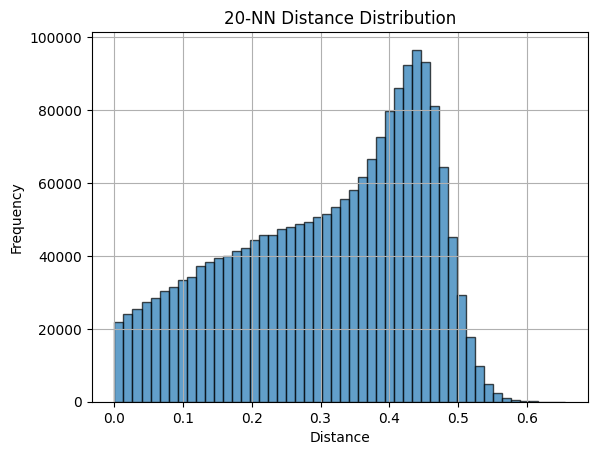

In [11]:
# # Apply it to the samples
# stats = global_analyze_sampling(samples_og, plot=True)
# Apply it to the samples
local_stats = analyze_local_uniformity(samples_og, k=20, plot=True)
